In [2]:
import sys
from pathlib import Path

def _find_project_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "utility.py").exists():
            return p
    return start

PROJECT_ROOT = _find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "data"


In [3]:
import sys
sys.path.append("../../..")
sys.path.append("../..")

In [4]:
import pandas as pd
import numpy as np
import fcgr
from Bio import SeqIO
from tqdm import tqdm
import os
from scipy.stats import ttest_ind
import glob
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
import utility
import json
# import keras
# import tensorflow as tf
import kaos


In [5]:
kmer_length = 10

# Resolve FASTA path from project data directory (avoid machine-specific absolute paths)
from pathlib import Path

_fasta_candidates = [
    Path(str(DATA_DIR / "GCF_000005845.2_ASM584v2_genomic.fna")),
    Path("data/GCF_000005845.2_ASM584v2_genomic.fna"),
]

fasta_file_path = None
for _cand in _fasta_candidates:
    if _cand.exists():
        fasta_file_path = str(_cand)
        break

if fasta_file_path is None:
    raise FileNotFoundError(
        "Could not find reference FASTA. Checked: "
        + ", ".join(str(x) for x in _fasta_candidates)
    )


In [6]:
# Function to extract flanks for each mutation
def extract_flanks(sequence, pos, alt_base, kmer_length):
    seq_length = len(sequence)
    # Define the flanking region around the mutation
    start = max(0, pos - kmer_length)
    end = min(seq_length, pos + kmer_length + 1)
    
    # Extract the reference flank
    ref_flank = sequence[start:end]
    
    # Create the alternate flank by introducing the mutation
    alt_flank = ref_flank[:(pos - start)] + alt_base + ref_flank[(pos - start + 1):]
    
    return ref_flank, alt_flank


def return_window_wise_kgain(data, pop_column, alt_flank_col, ref_flank_col,  kmer_length = 10, fcgr_dict=None, include_cols = None):
    import numpy as np
    import pandas as pd

    data = data.copy()

    data = data[include_cols].drop_duplicates()

    result_rows = []

    for _, row in data.iterrows():
        pop = row[pop_column]
        alt_seq = row[alt_flank_col]
        ref_seq = row[ref_flank_col]

        if len(ref_seq) < (2*kmer_length - 1) or len(alt_seq) < (2*kmer_length - 1):
            continue

        center = len(ref_seq) // 2
        gain = 0

        for j in range(kmer_length):
            aw = alt_seq[center - kmer_length + j + 1 : center + 1 + j]
            rw = ref_seq[center - kmer_length + j + 1 : center + 1 + j]
            if len(aw) != kmer_length or len(rw) != kmer_length:
                continue
            try:
                ratio = fcgr_dict[pop][aw] / fcgr_dict[pop][rw]
                window_gain = np.log(ratio)
            except KeyError:
                continue

            # gain += window_gain
            # build dict only with keys in include_cols + kmer info
            base = {col: row[col] for col in include_cols if col in row}
            base.update({
                'population': pop,
                'altered_sliding_window': aw,
                'reference_sliding_window': rw,
                'window_wise_gain': window_gain,
                # 'kgain': gain,
            })
            result_rows.append(base)

    return pd.DataFrame(result_rows)


def return_mutated_fasta(data, fasta_seq, generation_number, population_column, position_column, 
                         alt_base_column, ref_base_column, generation_column,
                         chromosome_column, gene_column):
    data = data.copy()

    # Only necessary columns and only current generation
    tmp = data[[population_column, chromosome_column, gene_column, position_column, ref_base_column, alt_base_column, generation_column]].drop_duplicates()
    tmp_df_new = tmp[tmp[generation_column] == generation_number]

    dct_fasta_sequence = dict()

    # Group by population_name, collect positions and ALTs for each population
    grouped = tmp_df_new.groupby(population_column)
    # print(grouped)

    for pop_name, group in grouped:

        seq_list = list(fasta_seq)  # Convert to mutable list

        # Efficiently mutate all at once
        for pos, alt in zip(group[position_column].astype(int), group[alt_base_column]):
            seq_index = pos - 1  # Convert to 0-based index
            if 0 <= seq_index < len(seq_list):
                seq_list[seq_index] = alt

        dct_fasta_sequence[pop_name] = ''.join(seq_list)

    return dct_fasta_sequence


In [7]:

# Input and output paths
vcf_dir = str(DATA_DIR / "vcf/")

# Define the headers you want
custom_headers = [
    "CHROM", "POS", "ID", "REF", "ALT", "QUAL", "INFO", "FORMAT", "SAMPLE_GENOTYPE",
    "CHROM_ANNOT", "START", "END", "GENE", "ANNOT_ID", "STRAND", "SOURCE"
]

# Initialize an empty list to hold data
all_data = []

# Get all VCF files in the directory
vcf_files = glob.glob(os.path.join(vcf_dir, "*_annotated.vcf"))

# Process each VCF file
for file_path in vcf_files:
    file_name = os.path.basename(file_path)  # Extract file name
    print(f"Processing file: {file_name}")
    
    with open(file_path, 'r') as f:
        for line in f:
            if not line.startswith("#"):  # Skip header lines
                # Split each row by tab
                columns = line.strip().split("\t")
                
                # Ensure sufficient columns exist for parsing
                if len(columns) >= 16:
                    # Extract standard VCF and annotation data
                    chrom = columns[0]
                    pos = columns[1]
                    vcf_id = columns[2]
                    ref = columns[3]
                    alt = columns[4]
                    qual = columns[5]
                    info = columns[7]
                    format_col = columns[8]
                    sample_data = columns[9]
                    chrom_annot = columns[10]
                    start = columns[11]
                    end = columns[12]
                    gene = columns[13]
                    annot_id = columns[14]
                    strand = columns[15]
                    
                    # Add the source column (file name)
                    row = [
                        chrom, pos, vcf_id, ref, alt, qual, info, format_col, sample_data,
                        chrom_annot, start, end, gene, annot_id, strand, file_name
                    ]
                    all_data.append(row)

# Convert all data to a single DataFrame
df_combined = pd.DataFrame(all_data, columns=custom_headers)


# Filter the data based on Qual >= 20
filtered_df = df_combined[df_combined['QUAL'].astype(float) >= 20]
filtered_df['DP'] = filtered_df['INFO'].str.extract(r'DP=(\d+)').astype(int)
filtered_df = filtered_df[filtered_df['DP'] >= 10]
# Filter rows where both REF and ALT are exactly 1 character long
filtered_df = filtered_df[(filtered_df['REF'].str.len() == 1) & (filtered_df['ALT'].str.len() == 1)]
# Reset the index for the filtered DataFrame
filtered_df.reset_index(drop=True, inplace=True)


# Load the single DNA sequence from the FASTA file
fasta_seq = next(SeqIO.parse(fasta_file_path, "fasta")).seq  # Assuming one sequence in the file
seq_length = len(fasta_seq)
fasta_seq_str = str(fasta_seq)

df_mutations = filtered_df.copy()


Processing file: F_annotated.vcf
Processing file: P2R3_annotated.vcf
Processing file: P1R3_annotated.vcf
Processing file: P2R1_annotated.vcf
Processing file: P3R1_annotated.vcf
Processing file: P1R1_annotated.vcf
Processing file: P4R1_annotated.vcf
Processing file: P5R3_annotated.vcf
Processing file: D4_annotated.vcf
Processing file: P4R3_annotated.vcf
Processing file: P5R1_annotated.vcf
Processing file: D5_annotated.vcf
Processing file: D3_annotated.vcf
Processing file: D2_annotated.vcf
Processing file: D1_annotated.vcf
Processing file: WT7_annotated.vcf
Processing file: P3R3_annotated.vcf


/tmp/ipykernel_571935/2174594284.py:59: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['DP'] = filtered_df['INFO'].str.extract(r'DP=(\d+)').astype(int)


In [8]:
df_mutations

,CHROM,POS,ID,REF,ALT,QUAL,INFO,FORMAT,SAMPLE_GENOTYPE,CHROM_ANNOT,START,END,GENE,ANNOT_ID,STRAND,SOURCE,DP
0,NC_000913.3,346287,.,C,T,7279.15,AB=0;ABP=0;AC=24;AF=1;AN=24;AO=225;CIGAR=1X;DP...,GT:DP:RO:QR:AO:QA,1/1/1/1/1/1/1/1/1/1/1/1/1/1/1/1/1/1/1/1/1/1/1/...,NC_000913.3,345665,346337,yahN,.,-,F_annotated.vcf,225
1,NC_000913.3,803662,.,C,A,7050.3,AB=0;ABP=0;AC=24;AF=1;AN=24;AO=218;CIGAR=1X;DP...,GT:DP:RO:QR:AO:QA,1/1/1/1/1/1/1/1/1/1/1/1/1/1/1/1/1/1/1/1/1/1/1/...,NC_000913.3,803502,805764,ybhJ,.,+,F_annotated.vcf,218
2,NC_000913.3,1905761,.,G,A,6079.12,AB=0;ABP=0;AC=24;AF=1;AN=24;AO=201;CIGAR=1X;DP...,GT:DP:RO:QR:AO:QA,1/1/1/1/1/1/1/1/1/1/1/1/1/1/1/1/1/1/1/1/1/1/1/...,NC_000913.3,1905687,1906254,mntP,.,+,F_annotated.vcf,203
3,NC_000913.3,2411051,.,G,C,6693.91,AB=0;ABP=0;AC=24;AF=1;AN=24;AO=208;CIGAR=1X;DP...,GT:DP:RO:QR:AO:QA,1/1/1/1/1/1/1/1/1/1/1/1/1/1/1/1/1/1/1/1/1/1/1/...,NC_000913.3,2409519,2411352,yfbS,.,-,F_annotated.vcf,208
4,NC_000913.3,3391407,.,A,C,103.465,AB=0.257282;ABP=108.422;AC=6;AF=0.25;AN=24;AO=...,GT:DP:RO:QR:AO:QA,0/0/0/0/0/0/0/0/0/0/0/0/0/0/0/0/0/0/1/1/1/1/1/...,NC_000913.3,3390582,3392028,tldD,.,-,F_annotated.vcf,206
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,NC_000913.3,803662,.,C,A,6211.35,AB=0;ABP=0;AC=24;AF=1;AN=24;AO=195;CIGAR=1X;DP...,GT:DP:RO:QR:AO:QA,1/1/1/1/1/1/1/1/1/1/1/1/1/1/1/1/1/1/1/1/1/1/1/...,NC_000913.3,803502,805764,ybhJ,.,+,P3R3_annotated.vcf,195
96,NC_000913.3,1905761,.,G,A,4940.21,AB=0;ABP=0;AC=24;AF=1;AN=24;AO=158;CIGAR=1X;DP...,GT:DP:RO:QR:AO:QA,1/1/1/1/1/1/1/1/1/1/1/1/1/1/1/1/1/1/1/1/1/1/1/...,NC_000913.3,1905687,1906254,mntP,.,+,P3R3_annotated.vcf,159
97,NC_000913.3,2411051,.,G,C,7037.78,AB=0;ABP=0;AC=24;AF=1;AN=24;AO=216;CIGAR=1X;DP...,GT:DP:RO:QR:AO:QA,1/1/1/1/1/1/1/1/1/1/1/1/1/1/1/1/1/1/1/1/1/1/1/...,NC_000913.3,2409519,2411352,yfbS,.,-,P3R3_annotated.vcf,216
98,NC_000913.3,3471791,.,C,T,4533.14,AB=0;ABP=0;AC=24;AF=1;AN=24;AO=140;CIGAR=1X;DP...,GT:DP:RO:QR:AO:QA,1/1/1/1/1/1/1/1/1/1/1/1/1/1/1/1/1/1/1/1/1/1/1/...,NC_000913.3,3471399,3473514,fusA,.,-,P3R3_annotated.vcf,140


In [9]:
# Step 3: Perform k-mer analysis on the mutations from your file
for idx, row in tqdm(df_mutations.iterrows(), desc="Processing Mutations", total=len(df_mutations)):
    pos = int(row['POS']) - 1  # Adjust for 0-based indexing
    ref_base = row['REF']  # Reference base
    alt_base = row['ALT']  # Alternate base
    source = row['SOURCE']  # Extract the SOURCE column
    
    # Extract flanking regions for the mutation
    ref_flank, alt_flank = extract_flanks(fasta_seq_str, pos, alt_base, kmer_length)
    df_mutations.loc[idx, "ref_flank"] = ref_flank
    df_mutations.loc[idx, "alt_flank"] = alt_flank

df_combined = df_mutations.copy()

for i in range(df_combined["SOURCE"].shape[0]):
    # if df_combined.loc[i, "SOURCE"].contains["D1"]:
    if "D1" in df_combined.loc[i, "SOURCE"]:
        df_combined.loc[i, "pop"] = "D"
        df_combined.loc[i, "generation"] = 1

    if "D2" in df_combined.loc[i, "SOURCE"]:
        df_combined.loc[i, "pop"] = "D"
        df_combined.loc[i, "generation"] = 2

    if "D3" in df_combined.loc[i, "SOURCE"]:
        df_combined.loc[i, "pop"] = "D"
        df_combined.loc[i, "generation"] = 3

    
    if "D4" in df_combined.loc[i, "SOURCE"]:
        df_combined.loc[i, "pop"] = "D"
        df_combined.loc[i, "generation"] = 4

    if "D5" in df_combined.loc[i, "SOURCE"]:
        df_combined.loc[i, "pop"] = "D"
        df_combined.loc[i, "generation"] = 5

    if "P1R1" in df_combined.loc[i, "SOURCE"]:
        df_combined.loc[i, "pop"] = "R1"
        df_combined.loc[i, "generation"] = 1

    if "P2R1" in df_combined.loc[i, "SOURCE"]:
        df_combined.loc[i, "pop"] = "R1"
        df_combined.loc[i, "generation"] = 2

    if "P3R1" in df_combined.loc[i, "SOURCE"]:
        df_combined.loc[i, "pop"] = "R1"
        df_combined.loc[i, "generation"] = 3

    
    if "P4R1" in df_combined.loc[i, "SOURCE"]:
        df_combined.loc[i, "pop"] = "R1"
        df_combined.loc[i, "generation"] = 4

    if "P5R1" in df_combined.loc[i, "SOURCE"]:
        df_combined.loc[i, "pop"] = "R1"
        df_combined.loc[i, "generation"] = 5

    if "P1R3" in df_combined.loc[i, "SOURCE"]:
        df_combined.loc[i, "pop"] = "R3"
        df_combined.loc[i, "generation"] = 1

    if "P2R3" in df_combined.loc[i, "SOURCE"]:
        df_combined.loc[i, "pop"] = "R3"
        df_combined.loc[i, "generation"] = 2

    if "P3R3" in df_combined.loc[i, "SOURCE"]:
        df_combined.loc[i, "pop"] = "R3"
        df_combined.loc[i, "generation"] = 3

    
    if "P4R3" in df_combined.loc[i, "SOURCE"]:
        df_combined.loc[i, "pop"] = "R3"
        df_combined.loc[i, "generation"] = 4

    if "P5R3" in df_combined.loc[i, "SOURCE"]:
        df_combined.loc[i, "pop"] = "R3"
        df_combined.loc[i, "generation"] = 5

# Define the groups to process
groups = ['D', 'R1', 'R3', 'WT7', 'F']

complete_data = pd.DataFrame(columns=['POS', 'GENE', 'REF', 'ALT', 'count'])

# Loop through each group and compute counts
for group in groups:

    # print(group)
    # Filter the DataFrame for the specific group (based on `SOURCE` containing group keyword)
    df_filtered = df_combined[df_combined["pop"]==group][['POS', 'GENE', 'REF', 'ALT']].value_counts().reset_index()
    df_filtered["pop"] = group
    complete_data = pd.concat([complete_data, df_filtered])
    

complete_data['mutation_type'] = complete_data['count'].apply(
    lambda x: 'fixed' if x >= 4 else 'not_fixed'
)


# Ensure numeric data types for the relevant columns
df_combined['AF'] = df_combined['INFO'].str.extract(r'AF=([\d\.]+)')
df_combined['AF'] = pd.to_numeric(df_combined['AF'], errors='coerce')

# Bug fix: NaN AF must not fall into 'AF = 1' via the else branch
df_combined['AF_category'] = df_combined['AF'].apply(
    lambda x: 'AF < 1' if (pd.notna(x) and x < 1) else ('AF = 1' if pd.notna(x) else np.nan)
)

df_combined_unique_complete = pd.merge(df_combined[['CHROM','POS', 'REF', 'ALT', 'GENE', "pop", 'ref_flank', 'generation', 'AF', 'AF_category']], complete_data, how="left")
# Bug fix: removed duplicate 'ALT' that was listed twice in the subset
df_combined_unique_complete = df_combined_unique_complete.drop_duplicates(subset=['CHROM','POS', 'REF', 'ALT', 'GENE', "ref_flank", "pop"])

Processing Mutations: 100%|██████████| 100/100 [00:00<00:00, 2708.55it/s]


In [10]:
# df_combined_unique_complete

In [11]:
# df_combined[['CHROM', 'POS', 'REF', 'ALT', 'GENE', "generation", "pop" ]].dropna()

##### Evolved kGain

In [12]:

kmer_length = 10
import kaos
seq_fasta = kaos.read_fasta(fasta_file_path)

dct_fasta_5 = return_mutated_fasta(data = df_combined[['CHROM', 'POS', 'REF', 'ALT', 'GENE', "generation", "pop" ]].dropna(), 
                                   fasta_seq = seq_fasta, generation_number = 5, population_column = "pop", position_column="POS", 
                         alt_base_column="ALT", ref_base_column ="REF", generation_column = "generation",
                         chromosome_column = "CHROM", gene_column = "GENE" )

fcgr_dict_evolved = dict()

for i in dct_fasta_5.keys():
    fcgr_dict_evolved[i] = kaos.chaos_frequency_dictionary(fasta_string= dct_fasta_5[i], kmer_length=kmer_length, pseudo_count=True, chaos_game_kmer_array=kaos.chaos_game_representation_key(kmer_length = kmer_length))

df_complete_evolved = return_window_wise_kgain(data=df_combined, pop_column = 'pop', alt_flank_col ='alt_flank',
                                                ref_flank_col = 'ref_flank',  kmer_length = kmer_length, 
                                                fcgr_dict=fcgr_dict_evolved,
                                        include_cols = ['CHROM', 'POS', 'REF', 'ALT', 'GENE','ref_flank', 'alt_flank', 'pop'])
df_complete_evolved.rename(columns={"window_wise_gain": "window_wise_evolved_kgain_5th_generation"}, inplace=True)
df_complete_updated_groupby_evolved = df_complete_evolved.groupby(['CHROM', "POS", "REF", "ALT", "pop", "GENE"])["window_wise_evolved_kgain_5th_generation"].sum().reset_index()
df_complete_updated_groupby_evolved.rename(columns={"window_wise_evolved_kgain_5th_generation": "evolved_kgain_5th_generation"}, inplace=True)

df_complete_updated_groupby_evolved


,CHROM,POS,REF,ALT,pop,GENE,evolved_kgain_5th_generation
0,NC_000913.3,1264069,G,C,R1,hemA,-0.680075
1,NC_000913.3,1905761,G,A,D,mntP,5.064879
2,NC_000913.3,1905761,G,A,R1,mntP,5.064879
3,NC_000913.3,1905761,G,A,R3,mntP,5.064879
4,NC_000913.3,220679,T,A,D,metQ,-10.422693
5,NC_000913.3,2411051,G,C,D,yfbS,-4.085327
6,NC_000913.3,2411051,G,C,R1,yfbS,-4.085327
7,NC_000913.3,2411051,G,C,R3,yfbS,-4.085327
8,NC_000913.3,3391407,A,C,R3,tldD,0.660522
9,NC_000913.3,3426468,G,A,D,rrlD,-6.536812


In [13]:
# kgain_wt: kGain of each mutation computed against the reference (WT) genome FCGR.
# dct_fasta_5 keys already identify which populations have mutations; reuse them.
fcgr_dict_wt = dict()

for i in dct_fasta_5.keys():
    fcgr_dict_wt[i] = kaos.chaos_frequency_dictionary(fasta_string= seq_fasta, kmer_length=kmer_length, pseudo_count=True, chaos_game_kmer_array=kaos.chaos_game_representation_key(kmer_length = kmer_length))

df_complete_wt = return_window_wise_kgain(data=df_combined, pop_column = 'pop', alt_flank_col ='alt_flank', 
                                       ref_flank_col = 'ref_flank',  kmer_length = kmer_length, fcgr_dict=fcgr_dict_wt,
                                        include_cols = ['CHROM', 'POS', 'REF', 'ALT', 'GENE','ref_flank', 'alt_flank', 'pop'])
df_complete_wt.rename(columns={"window_wise_gain": "window_wise_kgain_wt"}, inplace=True)

df_complete_updated_groupby_wt = df_complete_wt.groupby(['CHROM', "POS", "REF", "ALT", "pop", "GENE"])["window_wise_kgain_wt"].sum().reset_index()
df_complete_updated_groupby_wt.rename(columns={"window_wise_kgain_wt": "kgain_wt"}, inplace=True)

df_complete_updated_groupby_wt

,CHROM,POS,REF,ALT,pop,GENE,kgain_wt
0,NC_000913.3,1264069,G,C,R1,hemA,-3.406970
1,NC_000913.3,1905761,G,A,D,mntP,2.281896
2,NC_000913.3,1905761,G,A,R1,mntP,2.281896
3,NC_000913.3,1905761,G,A,R3,mntP,2.281896
4,NC_000913.3,220679,T,A,D,metQ,-10.422693
5,NC_000913.3,2411051,G,C,D,yfbS,-6.132888
6,NC_000913.3,2411051,G,C,R1,yfbS,-6.132888
7,NC_000913.3,2411051,G,C,R3,yfbS,-6.132888
8,NC_000913.3,3391407,A,C,R3,tldD,-2.793208
9,NC_000913.3,3426468,G,A,D,rrlD,-6.536812


In [14]:
df_full = pd.merge(df_complete_updated_groupby_wt, df_complete_updated_groupby_evolved)

In [15]:
# df_full

In [16]:
df_combined_unique_complete_full =  pd.merge(df_full, df_combined_unique_complete)

In [17]:
df_combined_unique_complete_full.shape

(27, 14)

In [18]:

def median_based_distance(group1, group2):
    """

    
    Parameters:
        group1: list or numpy array, first sample
        group2: list or numpy array, second sample
    
    Returns:
        d_median: float, effect size based on median and MAD
    """

    import numpy as np
    from scipy.stats import median_abs_deviation
    # Compute medians
    median1 = pd.Series(group1).median()
    median2 = pd.Series(group2).median()


    
    # Compute MAD (median absolute deviation)
    mad1 = median_abs_deviation(group1, nan_policy = "omit")  # Scale for consistency with std
    mad2 = median_abs_deviation(group2, nan_policy = "omit")



    # Compute pooled MAD
    n1, n2 = len(group1), len(group2)
    pooled_mad = np.sqrt(((n1 - 1) * mad1**2 + (n2 - 1) * mad2**2) / (n1 + n2 - 2))
    
    # Compute Cohen's d using median and MAD
    d_median = (median1 - median2) / pooled_mad if pooled_mad > 0 else np.nan
    
    return d_median

In [19]:
def get_significance_star(p):
    if p < 0.0001:
        return '****'
    elif p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return 'ns'


def return_box_with_p_effect_size(ax, data, x_columns, y_columns, group1_name, group2_name,
                                   y_pos, hue_columns=None, fontsize=5,
                                   alternative='greater', n_boot=2000, random_seed=42):
    """
    Annotate a grouped boxplot with Welch's t-test statistics, BH-adjusted p-values,
    bootstrapped 95% CIs, and effect sizes (reviewer-requested reporting standard).

    Reports per comparison:
      - Welch's t-test (one-sided: alternative)
      - sample sizes (n1, n2)
      - raw p-value
      - BH-adjusted p-value (corrected across all comparisons in this panel)
      - median-based effect size d
      - 95% CI [lower, upper] via nonparametric bootstrap (n_boot replicates, fixed seed)
    When n < 2 in either group, annotates "n<2, not tested" instead of NaN values.
    """
    from statsmodels.stats.multitest import multipletests

    def _bootstrap_ci(g1, g2, stat_fn, n_boot=2000, seed=42):
        rng = np.random.default_rng(seed)
        g1_arr = np.asarray(g1.dropna())
        g2_arr = np.asarray(g2.dropna())
        boot = [stat_fn(pd.Series(rng.choice(g1_arr, len(g1_arr), replace=True)),
                        pd.Series(rng.choice(g2_arr, len(g2_arr), replace=True)))
                for _ in range(n_boot)]
        return np.nanpercentile(boot, [2.5, 97.5])

    xtick_labels    = [t.get_text()         for t in ax.get_xticklabels()]
    xtick_positions = [t.get_position()[0]  for t in ax.get_xticklabels()]

    if hue_columns is not None:
        # Pass 1: collect raw stats for every x-tick category
        results   = []
        raw_pvals = []
        for label, pos in zip(xtick_labels, xtick_positions):
            data_tmp = data[data[x_columns] == label]
            g1 = data_tmp[data_tmp[hue_columns] == group1_name][y_columns].dropna()
            g2 = data_tmp[data_tmp[hue_columns] == group2_name][y_columns].dropna()
            n1, n2 = len(g1), len(g2)

            if n1 < 2 or n2 < 2:
                raw_pvals.append(np.nan)
                results.append(dict(label=label, pos=pos, n1=n1, n2=n2,
                                    p_raw=np.nan, d=np.nan, ci_lo=np.nan, ci_hi=np.nan,
                                    insufficient_n=True))
                continue

            p_raw    = ttest_ind(g1, g2, equal_var=False, nan_policy='omit',
                                 alternative=alternative).pvalue
            d        = median_based_distance(g1, g2)
            ci_lo, ci_hi = _bootstrap_ci(g1, g2, median_based_distance,
                                          n_boot=n_boot, seed=random_seed)
            raw_pvals.append(p_raw)
            results.append(dict(label=label, pos=pos, n1=n1, n2=n2,
                                p_raw=p_raw, d=d, ci_lo=ci_lo, ci_hi=ci_hi,
                                insufficient_n=False))

        # BH correction across all comparisons in this panel
        valid_idx = [i for i, p in enumerate(raw_pvals) if not np.isnan(p)]
        adj_pvals = [np.nan] * len(raw_pvals)
        if valid_idx:
            _, corrected, _, _ = multipletests(
                [raw_pvals[i] for i in valid_idx], method='fdr_bh')
            for j, i in enumerate(valid_idx):
                adj_pvals[i] = corrected[j]

        # Pass 2: annotate with full stats
        for i, r in enumerate(results):
            p_adj = adj_pvals[i]
            if r['insufficient_n']:
                # Bug fix: show informative label instead of NaN values on figure
                annot = f"n=({r['n1']},{r['n2']})\nn<2, not tested"
                print(f"{r['label']}: n=({r['n1']},{r['n2']}), n<2 — not tested")
            else:
                star  = get_significance_star(p_adj)
                annot = (f"{star}\n"
                         f"t-test ({alternative})\n"
                         f"n=({r['n1']},{r['n2']})\n"
                         f"p={r['p_raw']:.2e}\n"
                         f"p_adj(BH)={p_adj:.2e}\n"
                         f"d={r['d']:.2f}\n"
                         f"95%CI [{r['ci_lo']:.2f},{r['ci_hi']:.2f}]")
                print(f"{r['label']}: t-test ({alternative}), n=({r['n1']},{r['n2']}), "
                      f"p={r['p_raw']:.2e}, p_adj(BH)={p_adj:.2e}, "
                      f"d={r['d']:.2f}, 95%CI [{r['ci_lo']:.2f},{r['ci_hi']:.2f}]")
            ax.text(r['pos'], y_pos, annot, ha='center', fontsize=fontsize, color='red',
                    va='bottom', clip_on=False)
        return ax

    # Two-group case without hue
    if hue_columns is None and len(xtick_labels) == 2:
        g1 = data[data[x_columns] == group1_name][y_columns].dropna()
        g2 = data[data[x_columns] == group2_name][y_columns].dropna()
        n1, n2   = len(g1), len(g2)
        if n1 < 2 or n2 < 2:
            annot = f"n=({n1},{n2})\nn<2, not tested"
            ax.text(xtick_positions[0], y_pos, annot, ha='center', fontsize=fontsize,
                    color='red', va='bottom', clip_on=False)
            print(f"n=({n1},{n2}), n<2 — not tested")
            return ax
        p_raw    = ttest_ind(g1, g2, equal_var=False, nan_policy='omit',
                             alternative=alternative).pvalue
        star     = get_significance_star(p_raw)
        d        = median_based_distance(g1, g2)
        ci_lo, ci_hi = _bootstrap_ci(g1, g2, median_based_distance,
                                      n_boot=n_boot, seed=random_seed)
        pos   = xtick_positions[0]
        annot = (f"{star}\nt-test ({alternative})\nn=({n1},{n2})\n"
                 f"p={p_raw:.2e}\nd={d:.2f}\n95%CI [{ci_lo:.2f},{ci_hi:.2f}]")
        ax.text(pos, y_pos, annot, ha='center', fontsize=fontsize, color='red',
                va='bottom', clip_on=False)
        print(f"t-test ({alternative}), n=({n1},{n2}), p={p_raw:.2e}, "
              f"d={d:.2f}, 95%CI [{ci_lo:.2f},{ci_hi:.2f}]")
        return ax

In [20]:
df_combined_complete_full_generation_wise = pd.merge(df_combined, df_combined_unique_complete_full[['CHROM', 'POS', 'REF', 'ALT', 'pop', 'kgain_wt',
       'evolved_kgain_5th_generation', 'mutation_type']], how="left" )

In [25]:
df_combined_unique_complete_full["pop"].value_counts()

pop
D     12
R1     8
R3     7
Name: count, dtype: int64

##### Fig. 6b

D: t-test (greater), n=(6,6), p=1.87e-02, p_adj(BH)=5.60e-02, d=1.99, 95%CI [-0.24,13.63]
R1: t-test (greater), n=(5,3), p=2.00e-01, p_adj(BH)=2.00e-01, d=0.76, 95%CI [-8.41,25.86]
R3: t-test (greater), n=(5,2), p=1.23e-01, p_adj(BH)=1.84e-01, d=2.81, 95%CI [-0.68,11.81]


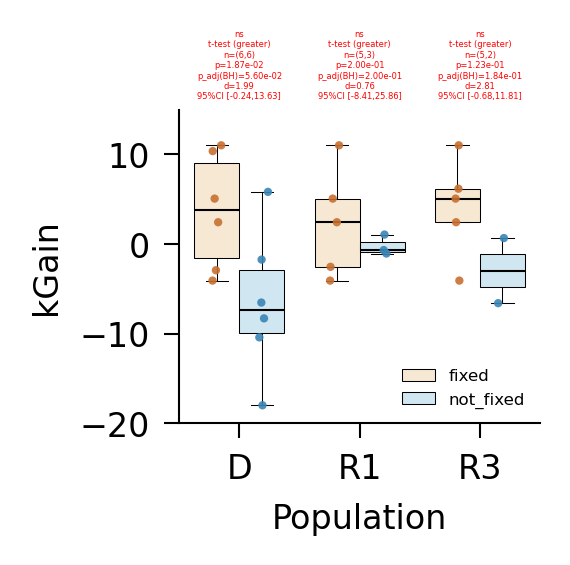

In [22]:
data = None
x_column = None
y_column = None
hue_column= None
group1_name = None
group2_name = None
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

DOT_PALETTE = {"fixed": "#C87030", "not_fixed": "#3A85B5"}
PALETTE     = {"fixed": "#FDE9CE", "not_fixed": "#CBE8F6"}

fig, ax = plt.subplots(1,1, figsize = (2, 2), dpi =300)
data = df_combined_unique_complete_full[df_combined_unique_complete_full["pop"].isin(["D", "R1", "R3"])].copy()
x_column = "pop"
y_column = 'evolved_kgain_5th_generation'
hue_column= 'mutation_type'
group1_name = "fixed"
group2_name = "not_fixed"
data.sort_values([x_column, hue_column], inplace=True)

ax = sns.boxplot(data=data, x=x_column, y=y_column, hue=hue_column,
    fliersize=0, linewidth=0.25, width=0.75,
    palette=PALETTE, dodge=True,
    boxprops={"edgecolor": "black", "linewidth": 0.25},
    whiskerprops={"color": "black", "linewidth": 0.25},
    capprops={"color": "black", "linewidth": 0.25},
    medianprops={"color": "black", "linewidth": 0.5})
ax = sns.stripplot(data=data, x=x_column, y=y_column, hue=hue_column,
    dodge=True, jitter=True, size=2, linewidth=0,
    palette=DOT_PALETTE, alpha=0.9, ax=ax)
ax = return_box_with_p_effect_size(ax=ax, data=data, x_columns=x_column, y_columns=y_column,
    group1_name=group1_name, group2_name=group2_name,
    y_pos=16, fontsize=2, hue_columns=hue_column, alternative='greater')

ax = utility.custom_figure_axis(ax, fontsize=8, rotation=0)
handles, labels = ax.get_legend_handles_labels()
n_hue = data[hue_column].nunique()
ax.legend(handles[:n_hue], labels[:n_hue], ncol=1, frameon=False, fontsize=4)
ax.tick_params(axis='x', which='both', labelsize=8, bottom=True, top=False, direction='out')
ax.tick_params(axis='y', which='both', labelsize=8, left=True, right=False, direction='out')
ax.set_ylabel("kGain")
ax.set_xlabel("Population")
ax.set_ylim(-20, 15)

plt.tight_layout()
plt.savefig("kGain vs population with synonymus mutation type.pdf", dpi=300)


##### Fig. 6c

D: t-test (greater), n=(8,4), p=1.75e-03, p_adj(BH)=3.51e-03, d=2.53, 95%CI [2.14,24.56]
R1: t-test (greater), n=(6,2), p=1.17e-01, p_adj(BH)=1.17e-01, d=0.75, 95%CI [-3.46,5.57]
R3: n=(6,1), n<2 — not tested


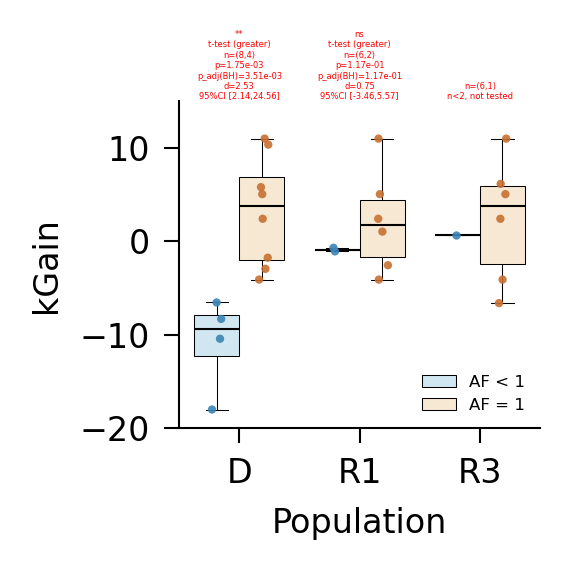

In [23]:
data = None
x_column = None
y_column = None
hue_column= None
group1_name = None
group2_name = None
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

DOT_PALETTE = {"AF = 1": "#C87030", "AF < 1": "#3A85B5"}
PALETTE = {"AF = 1": "#FDE9CE", "AF < 1": "#CBE8F6"}

fig, ax = plt.subplots(1,1, figsize = (2, 2), dpi =300)
# Bug fix: deduplicate to one row per unique mutation per population so that
# evolved_kgain_5th_generation (a static per-mutation value) is not repeated
# N times across generations, which would inflate sample size artificially.
data = (df_combined_complete_full_generation_wise[
            df_combined_complete_full_generation_wise["pop"].isin(["D", "R1", "R3"])]
        .drop_duplicates(subset=['CHROM', 'POS', 'REF', 'ALT', 'pop'])
        .copy())
x_column = "pop"
y_column = 'evolved_kgain_5th_generation'
hue_column= "AF_category"
group1_name = 'AF = 1'
group2_name = 'AF < 1'
data.sort_values([x_column, hue_column], inplace=True)

ax = sns.boxplot(data=data, x=x_column, y=y_column, hue=hue_column,
    fliersize=0, linewidth=0.25, width=0.75,
    palette=PALETTE, dodge=True,
    boxprops={"edgecolor": "black", "linewidth": 0.25},
    whiskerprops={"color": "black", "linewidth": 0.25},
    capprops={"color": "black", "linewidth": 0.25},
    medianprops={"color": "black", "linewidth": 0.5})
ax = sns.stripplot(data=data, x=x_column, y=y_column, hue=hue_column,
    dodge=True, jitter=True, size=2, linewidth=0,
    palette=DOT_PALETTE, alpha=0.9, ax=ax)
ax = return_box_with_p_effect_size(ax=ax, data=data, x_columns=x_column, y_columns=y_column,
    group1_name=group1_name, group2_name=group2_name,
    y_pos=15, fontsize=2, hue_columns=hue_column, alternative='greater')

ax = utility.custom_figure_axis(ax, fontsize=8, rotation=0)
handles, labels = ax.get_legend_handles_labels()
n_hue = data[hue_column].nunique()
ax.legend(handles[:n_hue], labels[:n_hue], ncol=1, frameon=False, fontsize=4)
ax.tick_params(axis='x', which='both', labelsize=8, bottom=True, top=False, direction='out')
ax.tick_params(axis='y', which='both', labelsize=8, left=True, right=False, direction='out')
ax.set_ylabel("kGain")
ax.set_xlabel("Population")
ax.set_ylim(-20, 15)

plt.tight_layout()
plt.savefig("kGain vs population AF wise lab data.pdf", dpi=300)


##### Unique mutation only

D: t-test (greater), n=(8,4), p=1.75e-03, p_adj(BH)=3.51e-03, d=2.53, 95%CI [2.14,20.48]
R1: t-test (greater), n=(6,2), p=1.17e-01, p_adj(BH)=1.17e-01, d=0.75, 95%CI [-3.46,5.57]
R3: n=(6,1), n<2 — not tested


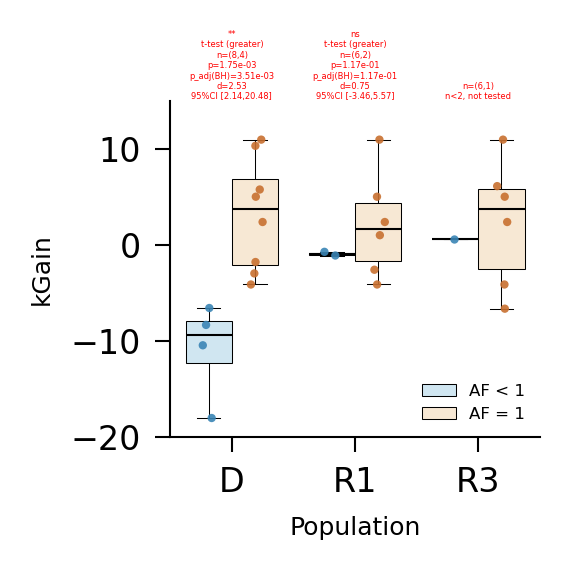

In [24]:
data = None
x_column = None
y_column = None
hue_column= None
group1_name = None
group2_name = None
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

DOT_PALETTE = {"AF = 1": "#C87030", "AF < 1": "#3A85B5"}
PALETTE = {"AF = 1": "#FDE9CE", "AF < 1": "#CBE8F6"}

fig, ax = plt.subplots(1,1, figsize = (2, 2), dpi =300)
data = df_combined_unique_complete_full[df_combined_unique_complete_full["pop"].isin(["D", "R1", "R3"])].copy()
x_column = "pop"
y_column = 'evolved_kgain_5th_generation'
hue_column= "AF_category"
group1_name = 'AF = 1'
group2_name = 'AF < 1'
data.sort_values([x_column, hue_column], inplace=True)

ax = sns.boxplot(data=data, x=x_column, y=y_column, hue=hue_column,
    fliersize=0, linewidth=0.25, width=0.75,
    palette=PALETTE, dodge=True,
    boxprops={"edgecolor": "black", "linewidth": 0.25},
    whiskerprops={"color": "black", "linewidth": 0.25},
    capprops={"color": "black", "linewidth": 0.25},
    medianprops={"color": "black", "linewidth": 0.5})
ax = sns.stripplot(data=data, x=x_column, y=y_column, hue=hue_column,
    dodge=True, jitter=True, size=2, linewidth=0,
    palette=DOT_PALETTE, alpha=0.9, ax=ax)
ax = return_box_with_p_effect_size(ax=ax, data=data, x_columns=x_column, y_columns=y_column,
    group1_name=group1_name, group2_name=group2_name,
    y_pos=15, fontsize=2, hue_columns=hue_column, alternative='greater')

ax = utility.custom_figure_axis(ax, fontsize=6, rotation=0)
handles, labels = ax.get_legend_handles_labels()
n_hue = data[hue_column].nunique()
ax.legend(handles[:n_hue], labels[:n_hue], ncol=1, frameon=False, fontsize=4)
ax.tick_params(axis='x', which='both', labelsize=8, bottom=True, top=False, direction='out')
ax.tick_params(axis='y', which='both', labelsize=8, left=True, right=False, direction='out')
ax.set_ylabel("kGain")
ax.set_xlabel("Population")
ax.set_ylim(-20, 15)

plt.tight_layout()
plt.savefig("kGain vs population AF wise lab data unique.pdf", dpi=300)
